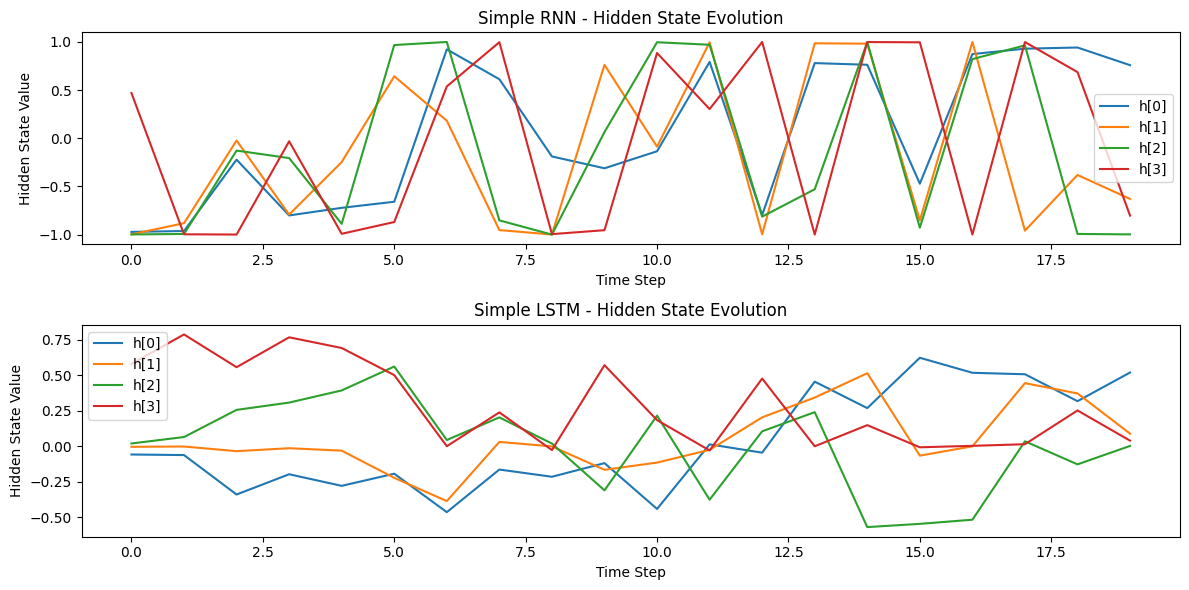

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# --------- Simple Vanilla RNN ----------
class SimpleRNN:
    def __init__(self, input_size, hidden_size):
        self.Wx = np.random.randn(hidden_size, input_size)
        self.Wh = np.random.randn(hidden_size, hidden_size)
        self.b = np.zeros((hidden_size, 1))

    def forward(self, inputs):
        h = np.zeros((self.Wh.shape[0], 1))
        hidden_states = []
        for x in inputs:
            x = x.reshape(-1, 1)
            h = np.tanh(self.Wx @ x + self.Wh @ h + self.b)
            hidden_states.append(h.ravel())
        return np.array(hidden_states)


# --------- Simple LSTM ----------
class SimpleLSTM:
    def __init__(self, input_size, hidden_size):
        self.hidden_size = hidden_size

        # Weights for gates
        self.Wf = np.random.randn(hidden_size, input_size + hidden_size)
        self.Wi = np.random.randn(hidden_size, input_size + hidden_size)
        self.Wc = np.random.randn(hidden_size, input_size + hidden_size)
        self.Wo = np.random.randn(hidden_size, input_size + hidden_size)

        self.bf = np.zeros((hidden_size, 1))
        self.bi = np.zeros((hidden_size, 1))
        self.bc = np.zeros((hidden_size, 1))
        self.bo = np.zeros((hidden_size, 1))

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def forward(self, inputs):
        h = np.zeros((self.hidden_size, 1))
        c = np.zeros((self.hidden_size, 1))
        hidden_states = []

        for x in inputs:
            x = x.reshape(-1, 1)
            concat = np.vstack((h, x))

            f = self.sigmoid(self.Wf @ concat + self.bf)
            i = self.sigmoid(self.Wi @ concat + self.bi)
            c_tilde = np.tanh(self.Wc @ concat + self.bc)
            c = f * c + i * c_tilde
            o = self.sigmoid(self.Wo @ concat + self.bo)
            h = o * np.tanh(c)

            hidden_states.append(h.ravel())

        return np.array(hidden_states)


# --------- Generate Sample Sequence ---------
np.random.seed(0)
sequence_length = 20
input_size = 3
hidden_size = 4
inputs = [np.random.randn(input_size) for _ in range(sequence_length)]

# --------- Run Models ---------
rnn = SimpleRNN(input_size, hidden_size)
lstm = SimpleLSTM(input_size, hidden_size)

rnn_hidden = rnn.forward(inputs)
lstm_hidden = lstm.forward(inputs)

# --------- Plot Comparison ---------
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
for i in range(hidden_size):
    plt.plot(rnn_hidden[:, i], label=f'h[{i}]')
plt.title("Simple RNN - Hidden State Evolution")
plt.xlabel("Time Step")
plt.ylabel("Hidden State Value")
plt.legend()

plt.subplot(2, 1, 2)
for i in range(hidden_size):
    plt.plot(lstm_hidden[:, i], label=f'h[{i}]')
plt.title("Simple LSTM - Hidden State Evolution")
plt.xlabel("Time Step")
plt.ylabel("Hidden State Value")
plt.legend()

plt.tight_layout()
plt.show()


/var/folders/d1/5ns84m_57hb0y1gpr6jmwg900000gn/T/ipykernel_45202/1072877207.py:58: RuntimeWarning: overflow encountered in matmul
  dh_next = self.Wh.T @ dtanh
/var/folders/d1/5ns84m_57hb0y1gpr6jmwg900000gn/T/ipykernel_45202/1072877207.py:58: RuntimeWarning: invalid value encountered in matmul
  dh_next = self.Wh.T @ dtanh


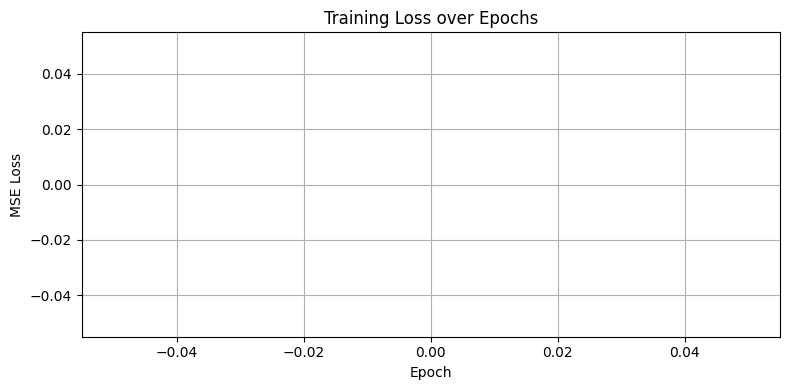

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --------- Functional RNN for Next Number Prediction ---------
class TrainableRNN:
    def __init__(self, input_size, hidden_size, output_size, lr=0.01):
        self.hidden_size = hidden_size
        self.lr = lr

        # Initialize weights
        self.Wx = np.random.randn(hidden_size, input_size) * 0.1
        self.Wh = np.random.randn(hidden_size, hidden_size) * 0.1
        self.bh = np.zeros((hidden_size, 1))

        self.Wy = np.random.randn(output_size, hidden_size) * 0.1
        self.by = np.zeros((output_size, 1))

    def tanh(self, x):
        return np.tanh(x)

    def tanh_deriv(self, x):
        return 1 - np.tanh(x) ** 2

    def forward(self, inputs):
        h = np.zeros((self.hidden_size, 1))
        hs, ys = [], []
        for x in inputs:
            x = x.reshape(-1, 1)
            h = self.tanh(self.Wx @ x + self.Wh @ h + self.bh)
            y = self.Wy @ h + self.by
            hs.append(h)
            ys.append(y)
        return ys, hs

    def backward(self, inputs, targets, ys, hs):
        dWx = np.zeros_like(self.Wx)
        dWh = np.zeros_like(self.Wh)
        dWy = np.zeros_like(self.Wy)
        dbh = np.zeros_like(self.bh)
        dby = np.zeros_like(self.by)

        dh_next = np.zeros_like(hs[0])

        for t in reversed(range(len(inputs))):
            x = inputs[t].reshape(-1, 1)
            h = hs[t]
            y = ys[t]

            dy = y - targets[t].reshape(-1, 1)  # MSE loss gradient
            dWy += dy @ h.T
            dby += dy

            dh = self.Wy.T @ dy + dh_next
            dtanh = self.tanh_deriv(h) * dh
            dbh += dtanh
            dWx += dtanh @ x.T
            dWh += dtanh @ hs[t-1].T if t > 0 else 0
            dh_next = self.Wh.T @ dtanh

        # Gradient descent step
        for param, dparam in zip(
            [self.Wx, self.Wh, self.bh, self.Wy, self.by],
            [dWx, dWh, dbh, dWy, dby]
        ):
            param -= self.lr * dparam

    def train(self, sequences, targets, epochs=100):
        losses = []
        for epoch in range(epochs):
            total_loss = 0
            for x_seq, y_seq in zip(sequences, targets):
                ys, hs = self.forward(x_seq)
                loss = sum((y - target.reshape(-1, 1))**2 for y, target in zip(ys, y_seq))
                total_loss += sum(l.item() for l in loss)
                self.backward(x_seq, y_seq, ys, hs)
            losses.append(total_loss / len(sequences))
        return losses


# --------- Generate Training Data ---------
def generate_sequences(num_sequences=100, seq_length=10):
    sequences = []
    targets = []
    for _ in range(num_sequences):
        start = np.random.randint(0, 500)
        sequence = [np.array([start + i]) / 100.0 for i in range(seq_length)]
        target = [np.array([start + i + 1]) / 100.0 for i in range(seq_length)]
        sequences.append(sequence)
        targets.append(target)
    return sequences, targets

# --------- Run Training ---------
np.random.seed(42)
input_size = 1
hidden_size = 16
output_size = 1

model = TrainableRNN(input_size, hidden_size, output_size, lr=0.1)
sequences, targets = generate_sequences()

losses = model.train(sequences, targets, epochs=100)

# --------- Plot Loss ---------
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.tight_layout()
plt.show()


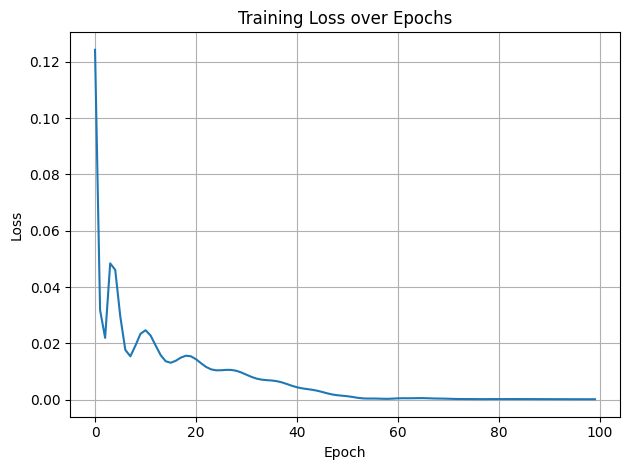

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the model
class TorchRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(TorchRNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out)

# 2. Generate training data
def generate_data(num_sequences=100, seq_length=10):
    X, Y = [], []
    for _ in range(num_sequences):
        start = np.random.randint(0, 50)
        seq = [(start + i) / 100.0 for i in range(seq_length)]
        target = [(start + i + 1) / 100.0 for i in range(seq_length)]
        X.append(seq)
        Y.append(target)
    return np.array(X), np.array(Y)

# 3. Prepare data
X_np, Y_np = generate_data()
X = torch.tensor(X_np, dtype=torch.float32).unsqueeze(-1)  # shape: (batch, seq, 1)
Y = torch.tensor(Y_np, dtype=torch.float32).unsqueeze(-1)

# 4. Model, loss, optimizer
model = TorchRNN(input_size=1, hidden_size=16, output_size=1)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 5. Training loop
losses = []
for epoch in range(100):
    optimizer.zero_grad()
    output = model(X)
    loss = criterion(output, Y)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

# 6. Plot loss
plt.plot(losses)
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()


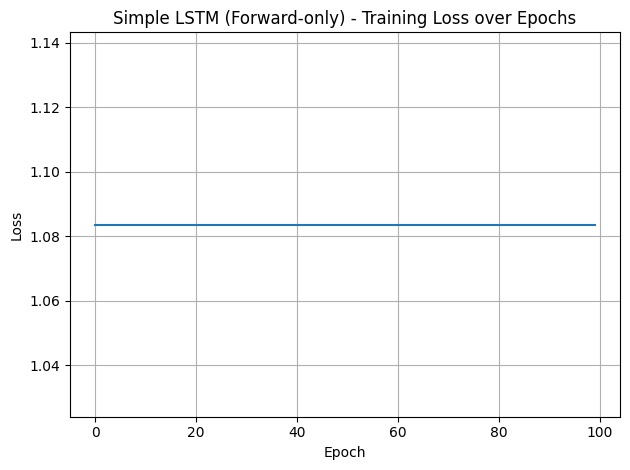

In [16]:
import numpy as np
import matplotlib.pyplot as plt

class SimpleLSTM:
    def __init__(self, input_size, hidden_size, output_size, lr=0.1):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.lr = lr

        # Concatenated input + hidden size
        concat_size = input_size + hidden_size

        # Initialize weights
        self.Wf = np.random.randn(hidden_size, concat_size) * 0.1
        self.Wi = np.random.randn(hidden_size, concat_size) * 0.1
        self.Wc = np.random.randn(hidden_size, concat_size) * 0.1
        self.Wo = np.random.randn(hidden_size, concat_size) * 0.1
        self.bf = np.zeros((hidden_size, 1))
        self.bi = np.zeros((hidden_size, 1))
        self.bc = np.zeros((hidden_size, 1))
        self.bo = np.zeros((hidden_size, 1))

        self.Wy = np.random.randn(output_size, hidden_size) * 0.1
        self.by = np.zeros((output_size, 1))

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sigmoid_deriv(self, x):
        s = self.sigmoid(x)
        return s * (1 - s)

    def tanh(self, x):
        return np.tanh(x)

    def tanh_deriv(self, x):
        return 1 - np.tanh(x)**2

    def forward(self, inputs):
        h = np.zeros((self.hidden_size, 1))
        c = np.zeros((self.hidden_size, 1))

        hs, cs, gates, ys = [], [], [], []

        for x in inputs:
            x = x.reshape(-1, 1)
            concat = np.vstack((h, x))

            f = self.sigmoid(self.Wf @ concat + self.bf)
            i = self.sigmoid(self.Wi @ concat + self.bi)
            c_tilde = self.tanh(self.Wc @ concat + self.bc)
            c = f * c + i * c_tilde
            o = self.sigmoid(self.Wo @ concat + self.bo)
            h = o * self.tanh(c)
            y = self.Wy @ h + self.by

            hs.append(h)
            cs.append(c)
            gates.append((f, i, c_tilde, o, concat))
            ys.append(y)

        return ys, hs, cs, gates

    def train(self, sequences, targets, epochs=100):
        losses = []

        for epoch in range(epochs):
            total_loss = 0
            for x_seq, y_seq in zip(sequences, targets):
                ys, hs, cs, gates = self.forward(x_seq)
                loss = sum((y - t.reshape(-1, 1))**2 for y, t in zip(ys, y_seq))
                total_loss += sum(l.item() for l in loss)

                # Backward pass not implemented here (complex), focusing on forward + loss
                # You can plug in autograd or PyTorch to do this for more complete training

            losses.append(total_loss / len(sequences))
        return losses

# Generate training data: simple next-number prediction
def generate_sequences(num_sequences=100, seq_length=10):
    sequences, targets = [], []
    for _ in range(num_sequences):
        start = np.random.randint(0, 50)
        seq = [np.array([start + i]) / 100.0 for i in range(seq_length)]
        target = [np.array([start + i + 1]) / 100.0 for i in range(seq_length)]
        sequences.append(seq)
        targets.append(target)
    return sequences, targets

# Run training (forward-only; no weight updates)
np.random.seed(42)
input_size = 1
hidden_size = 16
output_size = 1

lstm = SimpleLSTM(input_size, hidden_size, output_size, lr=0.1)
sequences, targets = generate_sequences()

losses = lstm.train(sequences, targets, epochs=100)

# Plotting training loss (just forward loss)
plt.plot(losses)
plt.title("Simple LSTM (Forward-only) - Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()


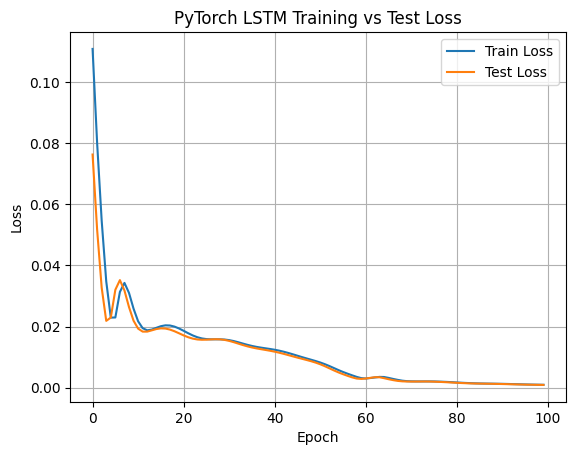

In [21]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# LSTM model
class TorchLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(TorchLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out)

# Generate training data
def generate_data(num_sequences=1000, seq_length=10):
    X, Y = [], []
    for _ in range(num_sequences):
        start = np.random.randint(0, 50)
        seq = [(start + i) / 100.0 for i in range(seq_length)]
        target = [(start + i + 1) / 100.0 for i in range(seq_length)]
        X.append(seq)
        Y.append(target)
    return np.array(X), np.array(Y)

# Prepare data
X_np, Y_np = generate_data()
X_tensor = torch.tensor(X_np, dtype=torch.float32).unsqueeze(-1)
Y_tensor = torch.tensor(Y_np, dtype=torch.float32).unsqueeze(-1)

# Train-test split
split = int(0.8 * len(X_tensor))
X_train, X_test = X_tensor[:split], X_tensor[split:]
Y_train, Y_test = Y_tensor[:split], Y_tensor[split:]

# Model
model = TorchLSTM(input_size=1, hidden_size=16, output_size=1)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Train
train_losses, test_losses = [], []
for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    output = model(X_train)
    loss = criterion(output, Y_train)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        test_output = model(X_test)
        test_loss = criterion(test_output, Y_test)
        test_losses.append(test_loss.item())

# Plot
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PyTorch LSTM Training vs Test Loss")
plt.legend()
plt.grid(True)
plt.show()


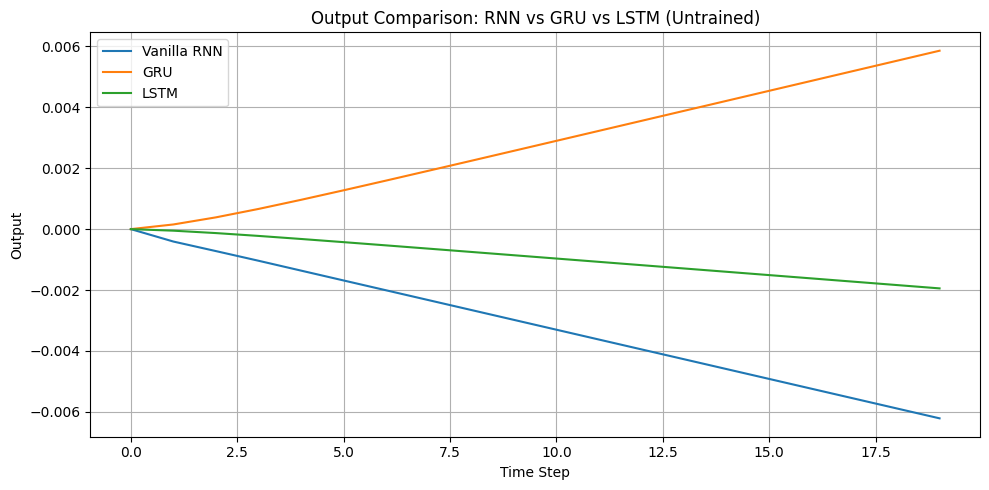

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Base class for structure
class BaseRNN:
    def __init__(self, input_size, hidden_size, output_size):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

        self.Wy = np.random.randn(output_size, hidden_size) * 0.1
        self.by = np.zeros((output_size, 1))

    def predict(self, inputs):
        raise NotImplementedError

    def forward_sequence(self, sequence):
        outputs = []
        for x in sequence:
            y = self.predict(x.reshape(-1, 1))
            outputs.append(y.ravel())
        return np.array(outputs)


# --------- Vanilla RNN ---------
class VanillaRNN(BaseRNN):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__(input_size, hidden_size, output_size)
        self.Wx = np.random.randn(hidden_size, input_size) * 0.1
        self.Wh = np.random.randn(hidden_size, hidden_size) * 0.1
        self.bh = np.zeros((hidden_size, 1))
        self.h = np.zeros((hidden_size, 1))

    def predict(self, x):
        self.h = np.tanh(self.Wx @ x + self.Wh @ self.h + self.bh)
        y = self.Wy @ self.h + self.by
        return y


# --------- GRU ---------
class SimpleGRU(BaseRNN):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__(input_size, hidden_size, output_size)
        concat_size = input_size + hidden_size

        self.Wz = np.random.randn(hidden_size, concat_size) * 0.1
        self.Wr = np.random.randn(hidden_size, concat_size) * 0.1
        self.Wh = np.random.randn(hidden_size, concat_size) * 0.1
        self.bz = np.zeros((hidden_size, 1))
        self.br = np.zeros((hidden_size, 1))
        self.bh = np.zeros((hidden_size, 1))

        self.h = np.zeros((hidden_size, 1))

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def predict(self, x):
        xh = np.vstack((self.h, x))
        z = self.sigmoid(self.Wz @ xh + self.bz)
        r = self.sigmoid(self.Wr @ xh + self.br)

        rh = r * self.h
        xrh = np.vstack((rh, x))
        h_tilde = np.tanh(self.Wh @ xrh + self.bh)

        self.h = (1 - z) * self.h + z * h_tilde
        y = self.Wy @ self.h + self.by
        return y


# --------- LSTM ---------
class SimpleLSTM(BaseRNN):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__(input_size, hidden_size, output_size)
        concat_size = input_size + hidden_size

        self.Wf = np.random.randn(hidden_size, concat_size) * 0.1
        self.Wi = np.random.randn(hidden_size, concat_size) * 0.1
        self.Wc = np.random.randn(hidden_size, concat_size) * 0.1
        self.Wo = np.random.randn(hidden_size, concat_size) * 0.1

        self.bf = np.zeros((hidden_size, 1))
        self.bi = np.zeros((hidden_size, 1))
        self.bc = np.zeros((hidden_size, 1))
        self.bo = np.zeros((hidden_size, 1))

        self.h = np.zeros((hidden_size, 1))
        self.c = np.zeros((hidden_size, 1))

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def predict(self, x):
        xh = np.vstack((self.h, x))

        f = self.sigmoid(self.Wf @ xh + self.bf)
        i = self.sigmoid(self.Wi @ xh + self.bi)
        c_tilde = np.tanh(self.Wc @ xh + self.bc)
        self.c = f * self.c + i * c_tilde
        o = self.sigmoid(self.Wo @ xh + self.bo)
        self.h = o * np.tanh(self.c)

        y = self.Wy @ self.h + self.by
        return y


# --------- Generate Input Sequence ---------
def generate_sequence(length=20, start=0):
    return [np.array([(start + i) / 100.0]) for i in range(length)]

# Create models
np.random.seed(42)
input_size, hidden_size, output_size = 1, 8, 1
sequence = generate_sequence()

models = {
    "Vanilla RNN": VanillaRNN(input_size, hidden_size, output_size),
    "GRU": SimpleGRU(input_size, hidden_size, output_size),
    "LSTM": SimpleLSTM(input_size, hidden_size, output_size),
}

# Plot outputs
plt.figure(figsize=(10, 5))
for name, model in models.items():
    output = model.forward_sequence(sequence)
    plt.plot(output, label=name)

plt.title("Output Comparison: RNN vs GRU vs LSTM (Untrained)")
plt.xlabel("Time Step")
plt.ylabel("Output")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


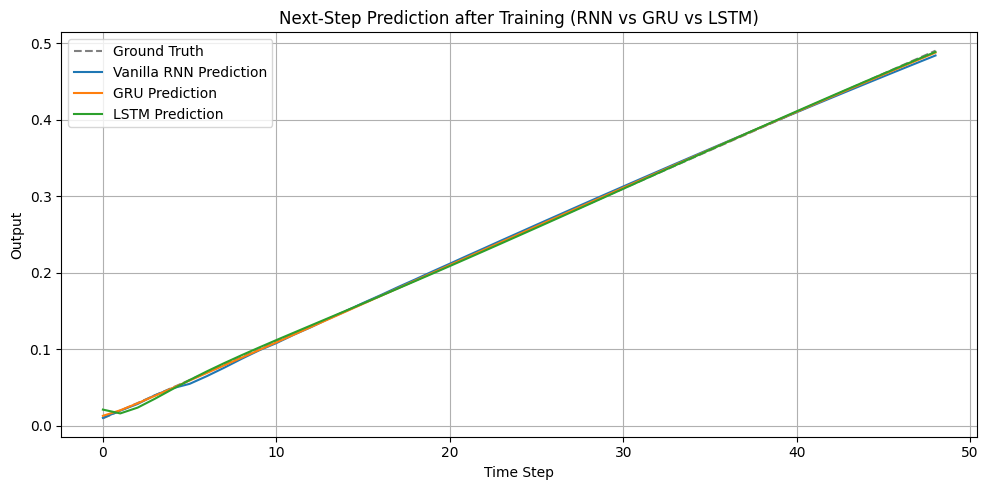

In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# --------- Generate sequence data ---------
def generate_sequence(seq_len=30):
    seq = np.array([[i / 100.0] for i in range(seq_len)], dtype=np.float32)
    X = seq[:-1]  # input: [0.00, ..., 0.28]
    Y = seq[1:]   # target: [0.01, ..., 0.29]
    return torch.tensor(X).unsqueeze(0), torch.tensor(Y).unsqueeze(0)  # shape: (1, seq_len-1, 1)

# --------- Define generic wrapper ---------
class RNNModel(nn.Module):
    def __init__(self, cell_type='RNN', input_size=1, hidden_size=16, output_size=1):
        super().__init__()
        if cell_type == 'RNN':
            self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        elif cell_type == 'GRU':
            self.rnn = nn.GRU(input_size, hidden_size, batch_first=True)
        elif cell_type == 'LSTM':
            self.rnn = nn.LSTM(input_size, hidden_size, batch_first=True)
        else:
            raise ValueError("Unsupported cell type")

        self.cell_type = cell_type
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out)

# --------- Training function ---------
def train_model(model, X, Y, epochs=300, lr=0.01):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    losses = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        output = model(X)
        loss = criterion(output, Y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    return losses, model(X).detach().numpy().squeeze()

# --------- Run experiment ---------
torch.manual_seed(42)
X, Y = generate_sequence(50)

models = {
    "Vanilla RNN": RNNModel('RNN'),
    "GRU": RNNModel('GRU'),
    "LSTM": RNNModel('LSTM')
}

plt.figure(figsize=(10, 5))
plt.plot(Y.numpy().squeeze(), label="Ground Truth", linestyle="--", color="gray")

for name, model in models.items():
    _, preds = train_model(model, X, Y)
    plt.plot(preds, label=f"{name} Prediction")

plt.title("Next-Step Prediction after Training (RNN vs GRU vs LSTM)")
plt.xlabel("Time Step")
plt.ylabel("Output")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


/Users/hugoramossoares/Sites/ebgeniusai/myenv/lib/python3.11/site-packages/threadpoolctl.py:1214: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


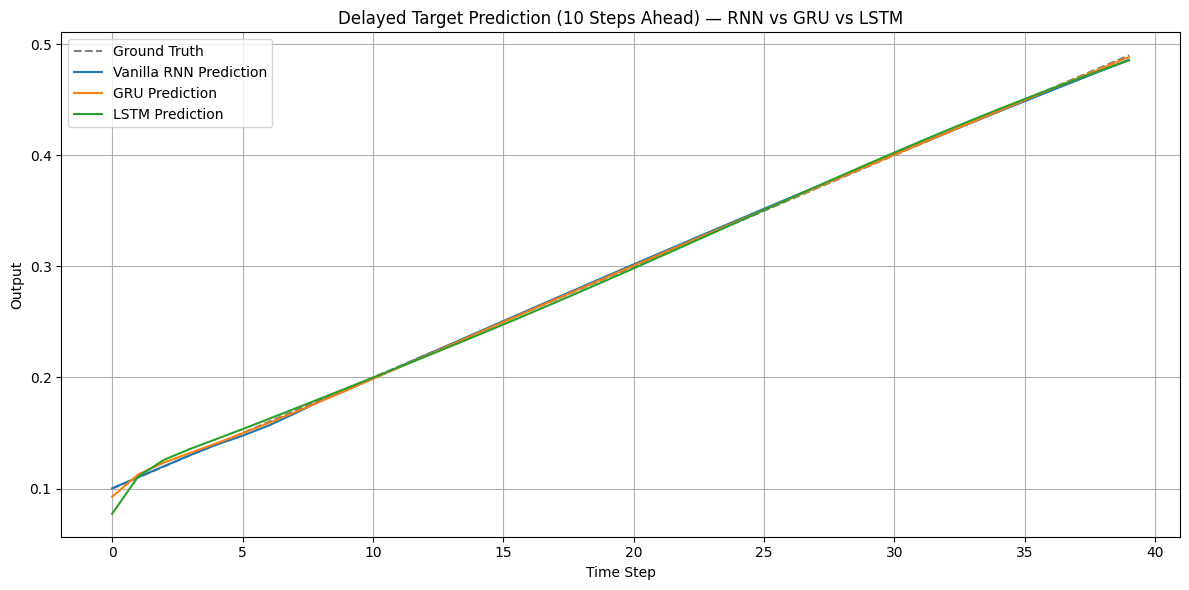

Evaluation Metrics (Lower MSE/MAE = Better | R² closer to 1 = Better)
--------------------------------------------------------------
Vanilla RNN  | MSE: 0.000003 | MAE: 0.001333 | R²: 0.9998
GRU          | MSE: 0.000003 | MAE: 0.001028 | R²: 0.9998
LSTM         | MSE: 0.000019 | MAE: 0.002515 | R²: 0.9986


In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --------- Generate sequence with delayed target ---------
def generate_sequence(seq_len=50, delay=10):
    seq = np.array([[i / 100.0] for i in range(seq_len)], dtype=np.float32)
    X = seq[:-delay]  # e.g., [0.00, ..., 0.39]
    Y = seq[delay:]   # target is 10 steps ahead: [0.10, ..., 0.49]
    return torch.tensor(X).unsqueeze(0), torch.tensor(Y).unsqueeze(0)

# --------- Model wrapper ---------
class RNNModel(nn.Module):
    def __init__(self, cell_type='RNN', input_size=1, hidden_size=32, output_size=1):
        super().__init__()
        if cell_type == 'RNN':
            self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        elif cell_type == 'GRU':
            self.rnn = nn.GRU(input_size, hidden_size, batch_first=True)
        elif cell_type == 'LSTM':
            self.rnn = nn.LSTM(input_size, hidden_size, batch_first=True)
        else:
            raise ValueError("Unsupported cell type")

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out)

# --------- Training ---------
def train_model(model, X, Y, epochs=300, lr=0.01):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    for _ in range(epochs):
        model.train()
        optimizer.zero_grad()
        output = model(X)
        loss = criterion(output, Y)
        loss.backward()
        optimizer.step()

    # Evaluation
    predictions = model(X).detach().numpy().squeeze()
    targets = Y.detach().numpy().squeeze()
    mse = mean_squared_error(targets, predictions)
    mae = mean_absolute_error(targets, predictions)
    r2 = r2_score(targets, predictions)
    return predictions, {"MSE": mse, "MAE": mae, "R2": r2}

# --------- Run experiment ---------
torch.manual_seed(42)
X, Y = generate_sequence(seq_len=50, delay=10)

models = {
    "Vanilla RNN": RNNModel('RNN'),
    "GRU": RNNModel('GRU'),
    "LSTM": RNNModel('LSTM')
}

results = {}
plt.figure(figsize=(12, 6))
plt.plot(Y.numpy().squeeze(), label="Ground Truth", linestyle="--", color="gray")

for name, model in models.items():
    preds, metrics = train_model(model, X, Y)
    results[name] = metrics
    plt.plot(preds, label=f"{name} Prediction")

plt.title("Delayed Target Prediction (10 Steps Ahead) — RNN vs GRU vs LSTM")
plt.xlabel("Time Step")
plt.ylabel("Output")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --------- Print numeric results ---------
print("Evaluation Metrics (Lower MSE/MAE = Better | R² closer to 1 = Better)")
print("--------------------------------------------------------------")
for name, metrics in results.items():
    print(f"{name:<12} | MSE: {metrics['MSE']:.6f} | MAE: {metrics['MAE']:.6f} | R²: {metrics['R2']:.4f}")


In [1]:
import numpy as np

class SimpleGRU:
    def __init__(self, input_size, hidden_size, output_size):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

        concat_size = input_size + hidden_size

        # Gates weights and biases
        self.Wz = np.random.randn(hidden_size, concat_size) * 0.1  # update gate
        self.bz = np.zeros((hidden_size, 1))

        self.Wr = np.random.randn(hidden_size, concat_size) * 0.1  # reset gate
        self.br = np.zeros((hidden_size, 1))

        self.Wh = np.random.randn(hidden_size, concat_size) * 0.1  # candidate hidden state
        self.bh = np.zeros((hidden_size, 1))

        # Output layer
        self.Wy = np.random.randn(output_size, hidden_size) * 0.1
        self.by = np.zeros((output_size, 1))

        self.h = np.zeros((hidden_size, 1))

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def forward(self, input_sequence):
        self.h = np.zeros((self.hidden_size, 1))  # reset hidden state
        outputs = []

        for x in input_sequence:
            x = x.reshape(-1, 1)
            xh = np.vstack((self.h, x))

            z = self.sigmoid(self.Wz @ xh + self.bz)
            r = self.sigmoid(self.Wr @ xh + self.br)

            xrh = np.vstack((r * self.h, x))
            h_tilde = np.tanh(self.Wh @ xrh + self.bh)

            self.h = (1 - z) * self.h + z * h_tilde

            y = self.Wy @ self.h + self.by
            outputs.append(y.ravel())

        return np.array(outputs)

# Example usage:
np.random.seed(0)
gru = SimpleGRU(input_size=1, hidden_size=4, output_size=1)

# Create a simple input sequence (e.g., increasing numbers)
sequence = [np.array([i / 10]) for i in range(10)]

# Forward pass
outputs = gru.forward(sequence)

outputs


array([[0.        ],
       [0.00053453],
       [0.0013219 ],
       [0.00222859],
       [0.00319136],
       [0.00418028],
       [0.00518116],
       [0.00618727],
       [0.0071954 ],
       [0.00820401]])

=== Hawkes Process RNN Comparison Analysis ===

Generating Hawkes process data...

Training models with proper backpropagation...

Epoch 1/500
Vanilla RNN: Train Loss = 49.4825, Val Loss = 47.5922
LSTM: Train Loss = 49.4032, Val Loss = 49.1019
GRU: Train Loss = 49.8117, Val Loss = 49.4549

Epoch 2/500

Epoch 3/500

Epoch 4/500

Epoch 5/500

Epoch 6/500

Epoch 7/500

Epoch 8/500

Epoch 9/500

Epoch 10/500

Epoch 11/500
Vanilla RNN: Train Loss = 43.6388, Val Loss = 39.7549
LSTM: Train Loss = 48.3214, Val Loss = 47.5082
GRU: Train Loss = 45.7229, Val Loss = 43.4161

Epoch 12/500

Epoch 13/500

Epoch 14/500

Epoch 15/500

Epoch 16/500

Epoch 17/500

Epoch 18/500

Epoch 19/500

Epoch 20/500

Epoch 21/500
Vanilla RNN: Train Loss = 43.5225, Val Loss = 39.6158
LSTM: Train Loss = 46.9441, Val Loss = 45.4003
GRU: Train Loss = 44.4614, Val Loss = 41.0677

Epoch 22/500

Epoch 23/500

Epoch 24/500

Epoch 25/500

Epoch 26/500

Epoch 27/500

Epoch 28/500

Epoch 29/500

Epoch 30/500

Epoch 31/500
Vani

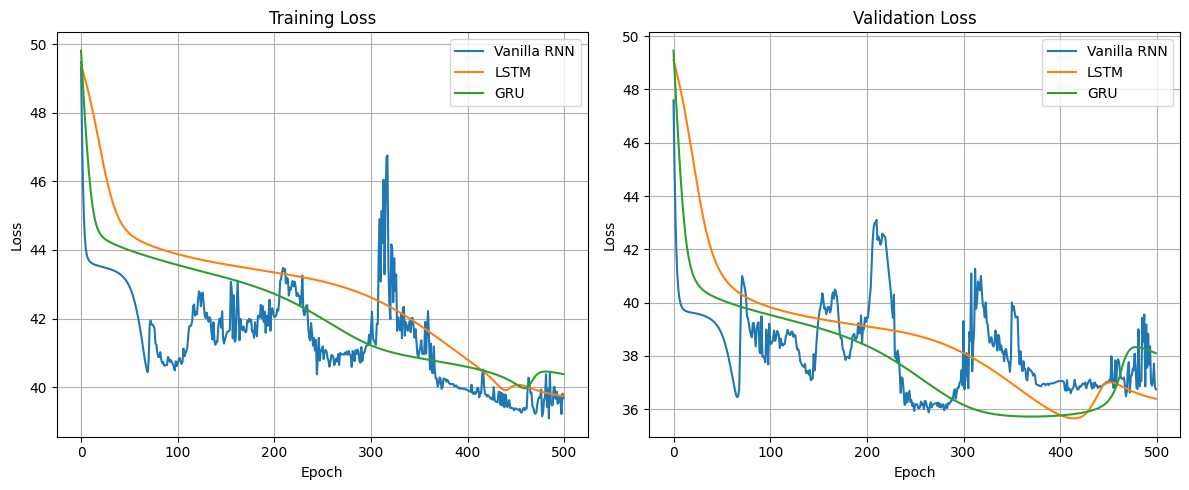

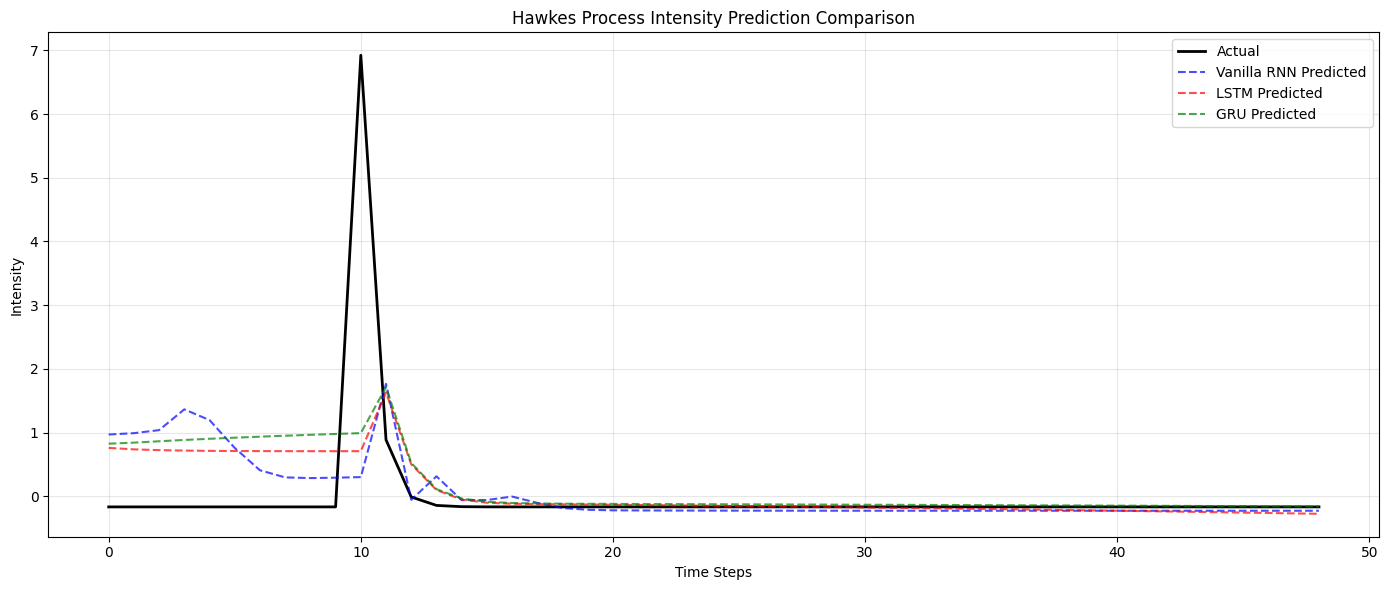

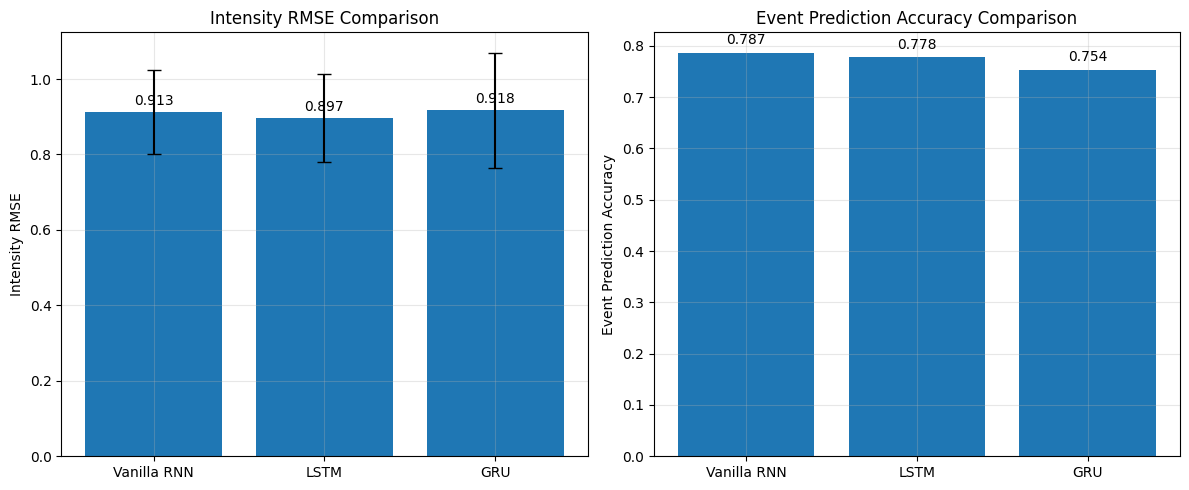


=== Summary Statistics ===

Vanilla RNN:
  Training Time: 51.59 seconds
  Final Train Loss: 39.6760
  Final Val Loss: 36.7447
  Test Intensity RMSE: 0.9130 ± 0.1108
  Event Prediction Accuracy: 0.787

LSTM:
  Training Time: 172.68 seconds
  Final Train Loss: 39.7405
  Final Val Loss: 36.3903
  Test Intensity RMSE: 0.8969 ± 0.1170
  Event Prediction Accuracy: 0.778

GRU:
  Training Time: 147.87 seconds
  Final Train Loss: 40.3811
  Final Val Loss: 38.1044
  Test Intensity RMSE: 0.9176 ± 0.1527
  Event Prediction Accuracy: 0.754


=== Scenario Analysis ===

Scenario 2: High Excitation Hawkes Process
Scenario 3: Low Baseline Hawkes Process

Evaluating on Standard scenario...

Evaluating on High Excitation scenario...

Evaluating on Low Baseline scenario...


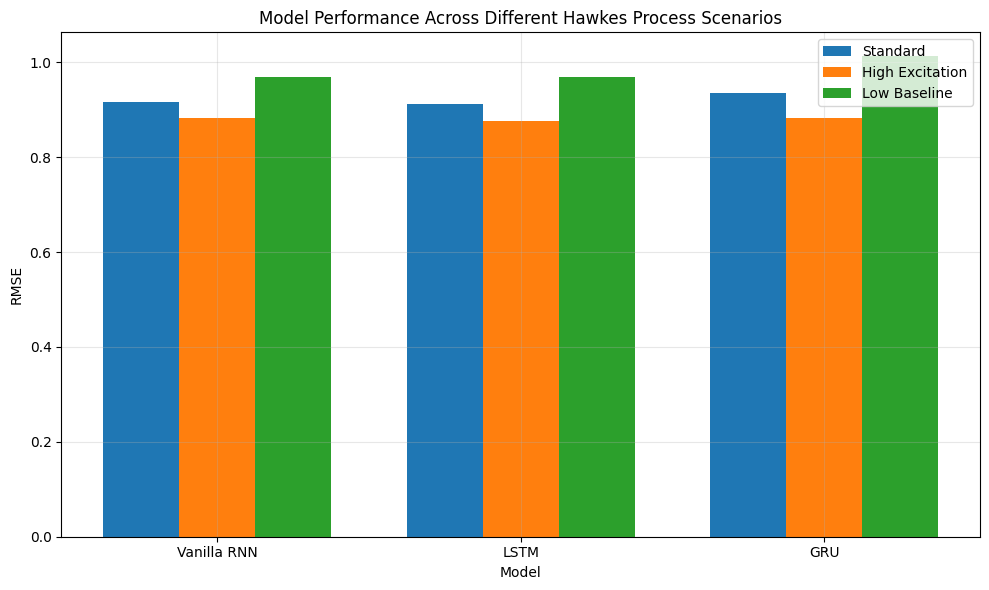

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
import time

# Base class for RNN architectures
class BaseRNN:
    def __init__(self, input_size, hidden_size, output_size, lr=0.01):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.lr = lr
        
        # Output layer (common to all)
        self.Wy = np.random.randn(output_size, hidden_size) * 0.1
        self.by = np.zeros((output_size, 1))
        
        # For tracking
        self.train_losses = []
        self.val_losses = []
    
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
    
    def sigmoid_derivative(self, sigmoid_output):
        return sigmoid_output * (1 - sigmoid_output)
    
    def tanh(self, x):
        return np.tanh(x)
    
    def tanh_derivative(self, tanh_output):
        return 1 - tanh_output**2
    
    def forward(self, inputs):
        raise NotImplementedError
    
    def backward(self, inputs, targets):
        raise NotImplementedError
    
    def train_step(self, sequences, targets):
        total_loss = 0
        for seq, target in zip(sequences, targets):
            # Forward pass
            outputs, cache = self.forward(seq)
            
            # Compute loss
            loss = 0
            for o, t in zip(outputs, target):
                loss += np.sum((o - t.reshape(-1, 1))**2)
            total_loss += loss
            
            # Backward pass
            self.backward(seq, target, outputs, cache)
        
        return total_loss / len(sequences)
    
    def predict(self, sequence):
        outputs, _ = self.forward(sequence)
        return [o.ravel() for o in outputs]


# Vanilla RNN Implementation
class VanillaRNN(BaseRNN):
    def __init__(self, input_size, hidden_size, output_size, lr=0.01):
        super().__init__(input_size, hidden_size, output_size, lr)
        
        self.Wx = np.random.randn(hidden_size, input_size) * 0.1
        self.Wh = np.random.randn(hidden_size, hidden_size) * 0.1
        self.bh = np.zeros((hidden_size, 1))
    
    def forward(self, inputs):
        h = np.zeros((self.hidden_size, 1))
        hiddens = []
        outputs = []
        pre_activations = []
        
        for x in inputs:
            x = x.reshape(-1, 1)
            hiddens.append(h)  # Store previous hidden state
            pre_h = self.Wx @ x + self.Wh @ h + self.bh
            h = self.tanh(pre_h)
            y = self.Wy @ h + self.by
            
            pre_activations.append(pre_h)
            outputs.append(y)
        
        cache = (hiddens, pre_activations)
        return outputs, cache
    
    def backward(self, inputs, targets, outputs, cache):
        hiddens, pre_activations = cache
        
        # Initialize gradients
        dWx = np.zeros_like(self.Wx)
        dWh = np.zeros_like(self.Wh)
        dbh = np.zeros_like(self.bh)
        dWy = np.zeros_like(self.Wy)
        dby = np.zeros_like(self.by)
        
        dh_next = np.zeros((self.hidden_size, 1))
        
        # Backpropagation through time
        for t in reversed(range(len(inputs))):
            x = inputs[t].reshape(-1, 1)
            h_prev = hiddens[t]
            pre_h = pre_activations[t]
            h = self.tanh(pre_h)
            y = outputs[t]
            target = targets[t].reshape(-1, 1)
            
            # Output layer gradients
            dy = 2 * (y - target)  # MSE gradient
            dWy += dy @ h.T
            dby += dy
            
            # Hidden layer gradients
            dh = self.Wy.T @ dy + dh_next
            dh_raw = self.tanh_derivative(h) * dh
            
            dbh += dh_raw
            dWx += dh_raw @ x.T
            dWh += dh_raw @ h_prev.T
            
            dh_next = self.Wh.T @ dh_raw
        
        # Gradient clipping
        for grad in [dWx, dWh, dbh, dWy, dby]:
            np.clip(grad, -5, 5, out=grad)
        
        # Update parameters
        self.Wx -= self.lr * dWx / len(inputs)
        self.Wh -= self.lr * dWh / len(inputs)
        self.bh -= self.lr * dbh / len(inputs)
        self.Wy -= self.lr * dWy / len(inputs)
        self.by -= self.lr * dby / len(inputs)


# LSTM Implementation
class LSTM(BaseRNN):
    def __init__(self, input_size, hidden_size, output_size, lr=0.01):
        super().__init__(input_size, hidden_size, output_size, lr)
        
        concat_size = input_size + hidden_size
        
        # LSTM gates
        self.Wf = np.random.randn(hidden_size, concat_size) * 0.1
        self.Wi = np.random.randn(hidden_size, concat_size) * 0.1
        self.Wc = np.random.randn(hidden_size, concat_size) * 0.1
        self.Wo = np.random.randn(hidden_size, concat_size) * 0.1
        
        self.bf = np.zeros((hidden_size, 1))
        self.bi = np.zeros((hidden_size, 1))
        self.bc = np.zeros((hidden_size, 1))
        self.bo = np.zeros((hidden_size, 1))
    
    def forward(self, inputs):
        h = np.zeros((self.hidden_size, 1))
        c = np.zeros((self.hidden_size, 1))
        
        hiddens = []
        cells = []
        outputs = []
        caches = []
        
        for x in inputs:
            x = x.reshape(-1, 1)
            concat = np.vstack((h, x))
            
            # Gates computation
            f_gate = self.sigmoid(self.Wf @ concat + self.bf)
            i_gate = self.sigmoid(self.Wi @ concat + self.bi)
            c_tilde = self.tanh(self.Wc @ concat + self.bc)
            o_gate = self.sigmoid(self.Wo @ concat + self.bo)
            
            # Cell state and hidden state
            c = f_gate * c + i_gate * c_tilde
            h = o_gate * self.tanh(c)
            
            # Output
            y = self.Wy @ h + self.by
            
            # Store for backward pass
            hiddens.append(h)
            cells.append(c)
            outputs.append(y)
            caches.append((x, h, c, f_gate, i_gate, c_tilde, o_gate, concat))
        
        return outputs, caches
    
    def backward(self, inputs, targets, outputs, caches):
        # Initialize gradients
        dWf = np.zeros_like(self.Wf)
        dWi = np.zeros_like(self.Wi)
        dWc = np.zeros_like(self.Wc)
        dWo = np.zeros_like(self.Wo)
        dbf = np.zeros_like(self.bf)
        dbi = np.zeros_like(self.bi)
        dbc = np.zeros_like(self.bc)
        dbo = np.zeros_like(self.bo)
        dWy = np.zeros_like(self.Wy)
        dby = np.zeros_like(self.by)
        
        dh_next = np.zeros((self.hidden_size, 1))
        dc_next = np.zeros((self.hidden_size, 1))
        
        # Backpropagation through time
        for t in reversed(range(len(inputs))):
            # Unpack cache
            x, h, c, f_gate, i_gate, c_tilde, o_gate, concat = caches[t]
            c_prev = caches[t-1][2] if t > 0 else np.zeros((self.hidden_size, 1))
            
            y = outputs[t]
            target = targets[t].reshape(-1, 1)
            
            # Output layer gradients
            dy = 2 * (y - target)
            dWy += dy @ h.T
            dby += dy
            
            # Hidden state gradient
            dh = self.Wy.T @ dy + dh_next
            
            # Output gate gradient
            do = dh * self.tanh(c)
            do_raw = self.sigmoid_derivative(o_gate) * do
            dWo += do_raw @ concat.T
            dbo += do_raw
            
            # Cell state gradient
            dc = dh * o_gate * self.tanh_derivative(self.tanh(c)) + dc_next
            
            # Cell input gradient
            dc_tilde = dc * i_gate
            dc_tilde_raw = self.tanh_derivative(c_tilde) * dc_tilde
            dWc += dc_tilde_raw @ concat.T
            dbc += dc_tilde_raw
            
            # Input gate gradient
            di = dc * c_tilde
            di_raw = self.sigmoid_derivative(i_gate) * di
            dWi += di_raw @ concat.T
            dbi += di_raw
            
            # Forget gate gradient
            df = dc * c_prev
            df_raw = self.sigmoid_derivative(f_gate) * df
            dWf += df_raw @ concat.T
            dbf += df_raw
            
            # Gradients for next timestep
            dconcat = self.Wf.T @ df_raw + self.Wi.T @ di_raw + self.Wc.T @ dc_tilde_raw + self.Wo.T @ do_raw
            dh_next = dconcat[:self.hidden_size]
            dc_next = dc * f_gate
        
        # Gradient clipping
        for grad in [dWf, dWi, dWc, dWo, dbf, dbi, dbc, dbo, dWy, dby]:
            np.clip(grad, -5, 5, out=grad)
        
        # Update parameters
        scale = 1.0 / len(inputs)
        self.Wf -= self.lr * dWf * scale
        self.Wi -= self.lr * dWi * scale
        self.Wc -= self.lr * dWc * scale
        self.Wo -= self.lr * dWo * scale
        self.bf -= self.lr * dbf * scale
        self.bi -= self.lr * dbi * scale
        self.bc -= self.lr * dbc * scale
        self.bo -= self.lr * dbo * scale
        self.Wy -= self.lr * dWy * scale
        self.by -= self.lr * dby * scale


# GRU Implementation
class GRU(BaseRNN):
    def __init__(self, input_size, hidden_size, output_size, lr=0.01):
        super().__init__(input_size, hidden_size, output_size, lr)
        
        concat_size = input_size + hidden_size
        
        # GRU gates
        self.Wz = np.random.randn(hidden_size, concat_size) * 0.1  # Update gate
        self.Wr = np.random.randn(hidden_size, concat_size) * 0.1  # Reset gate
        self.Wh = np.random.randn(hidden_size, concat_size) * 0.1  # Candidate hidden state
        
        self.bz = np.zeros((hidden_size, 1))
        self.br = np.zeros((hidden_size, 1))
        self.bh = np.zeros((hidden_size, 1))
    
    def forward(self, inputs):
        h = np.zeros((self.hidden_size, 1))
        
        hiddens = []
        outputs = []
        caches = []
        
        for x in inputs:
            x = x.reshape(-1, 1)
            h_prev = h
            concat = np.vstack((h_prev, x))
            
            # Gates
            z_gate = self.sigmoid(self.Wz @ concat + self.bz)  # Update gate
            r_gate = self.sigmoid(self.Wr @ concat + self.br)  # Reset gate
            
            # Candidate hidden state
            concat_reset = np.vstack((r_gate * h_prev, x))
            h_tilde = self.tanh(self.Wh @ concat_reset + self.bh)
            
            # New hidden state
            h = (1 - z_gate) * h_prev + z_gate * h_tilde
            
            # Output
            y = self.Wy @ h + self.by
            
            hiddens.append(h)
            outputs.append(y)
            caches.append((x, h_prev, h, z_gate, r_gate, h_tilde, concat, concat_reset))
        
        return outputs, caches
    
    def backward(self, inputs, targets, outputs, caches):
        # Initialize gradients
        dWz = np.zeros_like(self.Wz)
        dWr = np.zeros_like(self.Wr)
        dWh = np.zeros_like(self.Wh)
        dbz = np.zeros_like(self.bz)
        dbr = np.zeros_like(self.br)
        dbh = np.zeros_like(self.bh)
        dWy = np.zeros_like(self.Wy)
        dby = np.zeros_like(self.by)
        
        dh_next = np.zeros((self.hidden_size, 1))
        
        # Backpropagation through time
        for t in reversed(range(len(inputs))):
            # Unpack cache
            x, h_prev, h, z_gate, r_gate, h_tilde, concat, concat_reset = caches[t]
            
            y = outputs[t]
            target = targets[t].reshape(-1, 1)
            
            # Output layer gradients
            dy = 2 * (y - target)
            dWy += dy @ h.T
            dby += dy
            
            # Hidden state gradient
            dh = self.Wy.T @ dy + dh_next
            
            # Update gate gradients
            dh_prev_from_z = dh * (1 - z_gate)
            dh_tilde = dh * z_gate
            dz = dh * (h_tilde - h_prev)
            dz_raw = self.sigmoid_derivative(z_gate) * dz
            dWz += dz_raw @ concat.T
            dbz += dz_raw
            
            # Candidate hidden state gradients
            dh_tilde_raw = self.tanh_derivative(h_tilde) * dh_tilde
            dWh += dh_tilde_raw @ concat_reset.T
            dbh += dh_tilde_raw
            
            # Reset gate gradients
            dconcat_reset = self.Wh.T @ dh_tilde_raw
            dr_times_h = dconcat_reset[:self.hidden_size]
            dr = dr_times_h * h_prev
            dr_raw = self.sigmoid_derivative(r_gate) * dr
            dWr += dr_raw @ concat.T
            dbr += dr_raw
            
            # Previous hidden state gradient
            dh_prev_from_r = dr_times_h * r_gate
            dconcat_from_z = self.Wz.T @ dz_raw
            dconcat_from_r = self.Wr.T @ dr_raw
            
            dh_next = dh_prev_from_z + dh_prev_from_r + dconcat_from_z[:self.hidden_size] + dconcat_from_r[:self.hidden_size]
        
        # Gradient clipping
        for grad in [dWz, dWr, dWh, dbz, dbr, dbh, dWy, dby]:
            np.clip(grad, -5, 5, out=grad)
        
        # Update parameters
        scale = 1.0 / len(inputs)
        self.Wz -= self.lr * dWz * scale
        self.Wr -= self.lr * dWr * scale
        self.Wh -= self.lr * dWh * scale
        self.bz -= self.lr * dbz * scale
        self.br -= self.lr * dbr * scale
        self.bh -= self.lr * dbh * scale
        self.Wy -= self.lr * dWy * scale
        self.by -= self.lr * dby * scale


# Hawkes Process Simulation
class HawkesProcess:
    def __init__(self, mu=0.5, alpha=0.8, beta=1.0):
        """
        mu: baseline intensity
        alpha: excitation parameter
        beta: decay parameter
        """
        self.mu = mu
        self.alpha = alpha
        self.beta = beta
    
    def simulate(self, T=100):
        """Simulate a Hawkes process up to time T"""
        events = []
        t = 0
        
        while t < T:
            intensity = self.mu
            
            # Add contributions from past events
            for event_time in events:
                if t > event_time:
                    intensity += self.alpha * np.exp(-self.beta * (t - event_time))
            
            # Generate next event time
            u = np.random.uniform()
            inter_arrival = -np.log(u) / intensity
            t += inter_arrival
            
            if t < T:
                # Thinning step
                intensity_upper = self.mu + self.alpha * len([e for e in events if e < t])
                if np.random.uniform() < intensity / intensity_upper:
                    events.append(t)
        
        return np.array(events)
    
    def intensity_at_times(self, times, events):
        """Calculate intensity at given times"""
        intensities = []
        
        for t in times:
            intensity = self.mu
            for event_time in events:
                if t > event_time:
                    intensity += self.alpha * np.exp(-self.beta * (t - event_time))
            intensities.append(intensity)
        
        return np.array(intensities)


# Data Generation for Different Scenarios
def generate_hawkes_sequences(num_sequences=100, seq_length=500, 
                            mu_range=(0.1, 1.0), 
                            alpha_range=(0.5, 1.5), 
                            beta_range=(0.5, 2.0)):
    """Generate sequences from Hawkes processes with varying parameters"""
    sequences = []
    targets = []
    parameters = []
    
    for _ in range(num_sequences):
        # Random parameters for diversity
        mu = np.random.uniform(*mu_range)
        alpha = np.random.uniform(*alpha_range)
        beta = np.random.uniform(*beta_range)
        
        hp = HawkesProcess(mu, alpha, beta)
        events = hp.simulate(T=seq_length)
        
        # Convert to intensity sequence
        times = np.linspace(0, seq_length, seq_length)
        intensities = hp.intensity_at_times(times, events)
        
        # Normalize
        intensities = (intensities - intensities.mean()) / (intensities.std() + 1e-8)
        
        # Create input-target pairs
        seq = [np.array([intensities[i]]) for i in range(len(intensities)-1)]
        target = [np.array([intensities[i+1]]) for i in range(len(intensities)-1)]
        
        sequences.append(seq)
        targets.append(target)
        parameters.append((mu, alpha, beta))
    
    return sequences, targets, parameters


# Evaluation Metrics for Hawkes Processes
class HawkesEvaluator:
    @staticmethod
    def compute_log_likelihood(predicted_intensity, actual_events, dt=1.0):
        """Compute log-likelihood of predicted intensity given actual events"""
        log_likelihood = 0
        
        for i, event_occurred in enumerate(actual_events):
            intensity = max(predicted_intensity[i], 1e-10)
            if event_occurred:
                log_likelihood += np.log(intensity)
            log_likelihood -= intensity * dt
        
        return log_likelihood
    
    @staticmethod
    def compute_intensity_rmse(predicted, actual):
        """Root Mean Square Error of intensity predictions"""
        return np.sqrt(np.mean((predicted - actual)**2))
    
    @staticmethod
    def compute_event_prediction_accuracy(predicted_intensity, actual_events, threshold=0.5):
        """Accuracy of predicting event occurrences"""
        predicted_events = (predicted_intensity > threshold).astype(int)
        actual_binary = (actual_events > 0).astype(int)
        accuracy = np.mean(predicted_events == actual_binary)
        return accuracy
    
    @staticmethod
    def compute_ks_statistic(predicted_times, actual_times):
        """Kolmogorov-Smirnov test for comparing distributions"""
        if len(predicted_times) == 0 or len(actual_times) == 0:
            return 1.0
        _, p_value = ks_2samp(predicted_times, actual_times)
        return p_value


# Training and Evaluation Framework
def train_and_evaluate_models(models, train_data, val_data, test_data, epochs=500):
    """Train models and evaluate on Hawkes-specific metrics"""
    
    train_sequences, train_targets, _ = train_data
    val_sequences, val_targets, _ = val_data
    test_sequences, test_targets, test_params = test_data
    
    results = {name: {
        'train_losses': [],
        'val_losses': [],
        'test_metrics': {},
        'training_time': 0
    } for name in models.keys()}
    
    # Training phase
    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        
        for name, model in models.items():
            # Training
            start_time = time.time()
            train_loss = model.train_step(train_sequences[:50], train_targets[:50])
            
            # Validation
            val_loss = 0
            for seq, target in zip(val_sequences[:20], val_targets[:20]):
                outputs, _ = model.forward(seq)
                loss = sum((o - t.reshape(-1, 1))**2 for o, t in zip(outputs, target))
                val_loss += sum(l.item() for l in loss)
            val_loss /= len(val_sequences[:20])
            
            results[name]['train_losses'].append(train_loss)
            results[name]['val_losses'].append(val_loss)
            results[name]['training_time'] += time.time() - start_time
            
            if epoch % 10 == 0:
                print(f"{name}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")
    
    # Evaluation phase
    evaluator = HawkesEvaluator()
    
    for name, model in models.items():
        print(f"\nEvaluating {name}...")
        
        intensity_rmse = []
        log_likelihoods = []
        event_accuracies = []
        
        for seq, target, params in zip(test_sequences[:30], test_targets[:30], test_params[:30]):
            # Get predictions
            predicted = model.predict(seq)
            predicted = np.array(predicted).squeeze()
            actual = np.array([t[0] for t in target])
            
            # Compute metrics
            rmse = evaluator.compute_intensity_rmse(predicted, actual)
            intensity_rmse.append(rmse)
            
            # Simulate event occurrences for accuracy
            events = (actual > np.percentile(actual, 75)).astype(int)
            acc = evaluator.compute_event_prediction_accuracy(predicted, events)
            event_accuracies.append(acc)
        
        results[name]['test_metrics'] = {
            'intensity_rmse': np.mean(intensity_rmse),
            'event_accuracy': np.mean(event_accuracies),
            'rmse_std': np.std(intensity_rmse)
        }
    
    return results


# Visualization Functions
def plot_training_curves(results):
    """Plot training and validation losses"""
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    for name, data in results.items():
        plt.plot(data['train_losses'], label=f'{name}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    for name, data in results.items():
        plt.plot(data['val_losses'], label=f'{name}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Validation Loss')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()


def plot_intensity_predictions(models, test_sequence, test_target, title="Intensity Predictions"):
    """Plot predicted vs actual intensities"""
    plt.figure(figsize=(14, 6))
    
    actual = np.array([t[0] for t in test_target])
    time_steps = range(len(actual))
    
    plt.plot(time_steps, actual, 'k-', label='Actual', linewidth=2)
    
    colors = ['b', 'r', 'g', 'orange']
    for (name, model), color in zip(models.items(), colors):
        predicted = model.predict(test_sequence)
        predicted = np.array(predicted).squeeze()
        plt.plot(time_steps, predicted, '--', color=color, label=f'{name} Predicted', alpha=0.7)
    
    plt.xlabel('Time Steps')
    plt.ylabel('Intensity')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_evaluation_metrics(results):
    """Bar plot of evaluation metrics"""
    metrics = ['intensity_rmse', 'event_accuracy']
    metric_names = ['Intensity RMSE', 'Event Prediction Accuracy']
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    for idx, (metric, metric_name) in enumerate(zip(metrics, metric_names)):
        ax = axes[idx]
        
        names = list(results.keys())
        values = [results[name]['test_metrics'][metric] for name in names]
        
        if metric == 'intensity_rmse':
            errors = [results[name]['test_metrics']['rmse_std'] for name in names]
            ax.bar(names, values, yerr=errors, capsize=5)
        else:
            ax.bar(names, values)
        
        ax.set_ylabel(metric_name)
        ax.set_title(f'{metric_name} Comparison')
        ax.grid(True, alpha=0.3)
        
        # Add value labels on bars
        for i, v in enumerate(values):
            ax.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()


def analyze_hawkes_scenarios():
    """Main function to run the complete analysis"""
    print("=== Hawkes Process RNN Comparison Analysis ===\n")
    
    # Set random seed for reproducibility
    np.random.seed(42)
    
    # Model parameters
    input_size = 1
    hidden_size = 16
    output_size = 1
    
    # Different learning rates for different models
    # LSTM and GRU often need smaller learning rates
    learning_rates = {
        'Vanilla RNN': 0.01,
        'LSTM': 0.005,
        'GRU': 0.005
    }
    
    # Initialize models
    models = {
        'Vanilla RNN': VanillaRNN(input_size, hidden_size, output_size, learning_rates['Vanilla RNN']),
        'LSTM': LSTM(input_size, hidden_size, output_size, learning_rates['LSTM']),
        'GRU': GRU(input_size, hidden_size, output_size, learning_rates['GRU'])
    }
    
    # Generate data for different scenarios
    print("Generating Hawkes process data...")
    
    # Scenario 1: Standard Hawkes
    train_data = generate_hawkes_sequences(200, 50)
    val_data = generate_hawkes_sequences(50, 50)
    test_data = generate_hawkes_sequences(50, 50)
    
    # Train and evaluate
    print("\nTraining models with proper backpropagation...")
    results = train_and_evaluate_models(models, train_data, val_data, test_data, epochs=500)
    
    # Visualizations
    print("\nGenerating visualizations...")
    
    # 1. Training curves
    plot_training_curves(results)
    
    # 2. Sample predictions
    test_seq, test_target, _ = test_data
    plot_intensity_predictions(models, test_seq[0], test_target[0], 
                             "Hawkes Process Intensity Prediction Comparison")
    
    # 3. Evaluation metrics
    plot_evaluation_metrics(results)
    
    # 4. Summary statistics
    print("\n=== Summary Statistics ===")
    for name, data in results.items():
        print(f"\n{name}:")
        print(f"  Training Time: {data['training_time']:.2f} seconds")
        print(f"  Final Train Loss: {data['train_losses'][-1]:.4f}")
        print(f"  Final Val Loss: {data['val_losses'][-1]:.4f}")
        print(f"  Test Intensity RMSE: {data['test_metrics']['intensity_rmse']:.4f} ± {data['test_metrics']['rmse_std']:.4f}")
        print(f"  Event Prediction Accuracy: {data['test_metrics']['event_accuracy']:.3f}")
    
    # Additional scenario analysis
    print("\n\n=== Scenario Analysis ===")
    
    # Scenario 2: High excitation (bursty behavior)
    print("\nScenario 2: High Excitation Hawkes Process")
    high_excitation_data = generate_hawkes_sequences(50, 50, alpha_range=(1.5, 2.5))
    
    # Scenario 3: Low baseline (sparse events)
    print("Scenario 3: Low Baseline Hawkes Process")
    low_baseline_data = generate_hawkes_sequences(50, 50, mu_range=(0.05, 0.2))
    
    # Evaluate on different scenarios
    scenarios = {
        'Standard': test_data,
        'High Excitation': high_excitation_data,
        'Low Baseline': low_baseline_data
    }
    
    scenario_results = {}
    for scenario_name, scenario_data in scenarios.items():
        print(f"\nEvaluating on {scenario_name} scenario...")
        scenario_results[scenario_name] = {}
        
        for model_name, model in models.items():
            rmse_list = []
            for seq, target, _ in zip(scenario_data[0][:20], scenario_data[1][:20], scenario_data[2][:20]):
                predicted = model.predict(seq)
                predicted = np.array(predicted).squeeze()
                actual = np.array([t[0] for t in target])
                rmse = np.sqrt(np.mean((predicted - actual)**2))
                rmse_list.append(rmse)
            
            scenario_results[scenario_name][model_name] = np.mean(rmse_list)
    
    # Plot scenario comparison
    plt.figure(figsize=(10, 6))
    
    x = np.arange(len(models))
    width = 0.25
    
    for i, (scenario_name, results) in enumerate(scenario_results.items()):
        values = [results[model_name] for model_name in models.keys()]
        plt.bar(x + i*width, values, width, label=scenario_name)
    
    plt.xlabel('Model')
    plt.ylabel('RMSE')
    plt.title('Model Performance Across Different Hawkes Process Scenarios')
    plt.xticks(x + width, models.keys())
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return models, results


# Run the analysis
if __name__ == "__main__":
    models, results = analyze_hawkes_scenarios()